# 🚗 Toronto Traffic Collision Severity Prediction
## Notebook 4 of 5 — Model Training & Evaluation

**Author:** Nishi Bhavesh Patel | Student ID: 501356244

---

###  Filename note for Notebook 5:
The single-split table now saves to `model_results_single_split.csv` (diagnostic only).
`model_results.csv` — the file Notebook 5 reads — now contains the **CV-based** comparison
instead. The `Model` column name is preserved so `results_df.iloc[0]['Model']` still works
in Notebook 5 without changes.

### Input:  `collisions_cleaned.csv`
### Output: `trained_models.pkl`, `X_test.csv`, `y_test.csv`, `model_results.csv`,
`model_results_single_split.csv`, `cv_results.csv` *(now redundant with `model_results.csv`,
kept for backward compatibility)*


## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import pickle
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    average_precision_score, make_scorer,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

CLEANED_FILE  = '../MRP - Final Sem/Data/collisions_cleaned.csv'
MODELS_FOLDER = '../MRP - Final Sem/Models/'
PLOTS_FOLDER  = '../MRP - Final Sem/Plots/'
os.makedirs(MODELS_FOLDER, exist_ok=True)
os.makedirs(PLOTS_FOLDER,  exist_ok=True)

RANDOM_STATE    = 42
severity_labels = {0:'Minor', 1:'Major', 2:'Fatal'}
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded!')


Libraries loaded!


## Step 2 — Load Data

In [2]:
df = pd.read_csv(CLEANED_FILE, low_memory=False)
print(f'Loaded: {df.shape}')


Loaded: (677056, 44)


## Step 3 — Build Feature Matrix X and Target y

In [3]:
DROP_COLS = [
    'severity', 'OCC_DATE', 'datetime',
    'FATALITIES', 'INJURY_COLLISIONS', 'PD_COLLISIONS', 'FTR_COLLISIONS',
    'NEIGHBOURHOOD_158', 'DIVISION', 'weather_desc', 'geometry',
    '_id', 'OBJECTID', 'INDEX_', 'x', 'y'
]
drop_cols    = [c for c in DROP_COLS if c in df.columns]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df['severity'].copy()

print(f'Features: {X.shape[1]} columns')
print(f'Rows:     {X.shape[0]:,}')
print(f'NaN before fix: {X.isnull().sum().sum():,}')


Features: 33 columns
Rows:     677,056


NaN before fix: 0


## Step 4 — Fix All NaN Values

This step MUST run before the train/test split and before SMOTE-NC.

In [ ]:
nan_report = X.isnull().sum()
nan_cols   = nan_report[nan_report > 0].sort_values(ascending=False)
print(f'Columns with NaN: {len(nan_cols)}')
if len(nan_cols) > 0:
    print(nan_cols.to_string())


In [40]:
# A: Convert object/bool columns to numeric codes
for col in X.select_dtypes(include=['object','bool']).columns:
    X[col] = pd.Categorical(X[col]).codes

# B: Drop columns where ALL values are NaN
all_nan = [c for c in X.columns if X[c].isnull().all()]
if all_nan:
    print(f'Dropping fully-empty columns: {all_nan}')
    X = X.drop(columns=all_nan)

# C: Drop columns where more than 80% are NaN
mostly_nan = [c for c in X.columns if X[c].isnull().mean() > 0.8]
if mostly_nan:
    print(f'Dropping >80% NaN columns: {mostly_nan}')
    X = X.drop(columns=mostly_nan)

# D: Fill remaining NaN with median (0 if median itself is NaN)
for col in X.columns:
    if X[col].isnull().any():
        med = X[col].median()
        X[col] = X[col].fillna(med if pd.notna(med) else 0)

# E: Last resort — drop any remaining NaN rows
if X.isnull().sum().sum() > 0:
    mask = X.isnull().any(axis=1)
    before = len(X)
    X = X[~mask]
    y = y[~mask]
    print(f'Dropped {before - len(X)} rows with remaining NaN')

final_nan = X.isnull().sum().sum()
print(f'\nNaN remaining: {final_nan}')
print('✅ Ready for SMOTE-NC!' if final_nan == 0 else '❌ Still has NaN!')
print(f'Shape: {X.shape}')
print(f'\nClass distribution:')
for k, v in y.value_counts().sort_index().items():
    print(f'  {severity_labels[k]:8s}: {v:,} ({v/len(y)*100:.1f}%)')



NaN remaining: 0
✅ Ready for SMOTE-NC!
Shape: (677056, 33)

Class distribution:
  Minor   : 580,492 (85.7%)
  Major   : 95,928 (14.2%)
  Fatal   : 636 (0.1%)


## Step 5 — Identify Categorical Features (for SMOTE-NC)

Plain SMOTE treats every column as continuous and interpolates between values — which is
fine for `temperature`, but nonsensical for a one-hot column like `season_Spring`, where
the only valid values are 0 and 1. SMOTE-NC needs to be told which columns are categorical
so it samples those correctly (nearest-neighbour majority vote) instead of interpolating them.

Marked as categorical: the one-hot encoded groups from Notebook 2 (`OCC_DOW_*`, `season_*`,
`hour_category_*`) and the binary flag columns. Everything else is treated as continuous.

In [6]:
categorical_prefixes = ('OCC_DOW_', 'season_', 'hour_category_')
categorical_binary_flags = ['is_weekend', 'is_night', 'is_rain', 'is_snow', 'is_ice', 'adverse_weather_w']

categorical_cols = [c for c in X.columns if c.startswith(categorical_prefixes) or c in categorical_binary_flags]
# NOTE: must be a plain Python list of integer positions, not a numpy boolean array —
# some imblearn versions raise "truth value of array is ambiguous" internally otherwise.
categorical_indices = [X.columns.get_loc(c) for c in categorical_cols]
continuous_cols = [c for c in X.columns if c not in categorical_cols]

print(f'Categorical (one-hot / binary) columns: {len(categorical_cols)}')
for c in categorical_cols:
    print(f'  - {c}')
print(f'\nContinuous columns ({len(continuous_cols)}) — SMOTE-NC interpolates these normally:')
for c in continuous_cols:
    print(f'  - {c}')


Categorical (one-hot / binary) columns: 21
  - is_rain
  - is_snow
  - is_ice
  - adverse_weather_w
  - is_weekend
  - is_night
  - OCC_DOW_Friday
  - OCC_DOW_Monday
  - OCC_DOW_Saturday
  - OCC_DOW_Sunday
  - OCC_DOW_Thursday
  - OCC_DOW_Tuesday
  - OCC_DOW_Wednesday
  - season_Fall
  - season_Spring
  - season_Summer
  - season_Winter
  - hour_category_late_night
  - hour_category_offpeak
  - hour_category_peak
  - hour_category_weekend

Continuous columns (12) — SMOTE-NC interpolates these normally:
  - OCC_MONTH
  - OCC_YEAR
  - OCC_HOUR
  - HOOD_158
  - LONG_WGS84
  - LAT_WGS84
  - AUTOMOBILE
  - temperature
  - humidity
  - dew_point
  - precipitation
  - neighbourhood_freq


## Step 6 — Train / Validation / Test Split

Kept for diagnostics that need actual held-out predictions: confusion matrices, threshold tuning, subgroup analysis.

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f'Train:      {len(X_train):,}')
print(f'Validation: {len(X_val):,}')
print(f'Test:       {len(X_test):,}')
print(f'NaN in train: {X_train.isnull().sum().sum()}  ✓')

X_test.to_csv(f'{MODELS_FOLDER}X_test.csv', index=False)
y_test.to_csv(f'{MODELS_FOLDER}y_test.csv', index=False)
print('Test set saved for Notebook 5')


Train:      473,939
Validation: 101,558
Test:       101,559
NaN in train: 0  ✓
Test set saved for Notebook 5


## Step 7 — Apply SMOTE-NC

Only applied to the training split — validation/test stay at the real-world class balance.

In [8]:
print('Applying SMOTE-NC (categorical-aware SMOTE) to training data only...')
print(f'Using {len(categorical_indices)} categorical feature(s), '
      f'{X_train.shape[1]-len(categorical_indices)} continuous feature(s)')

sm = SMOTENC(categorical_features=categorical_indices, random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('\nAfter SMOTE-NC — training class distribution:')
for u, c in zip(*np.unique(y_train_sm, return_counts=True)):
    print(f'  {severity_labels[u]:8s}: {c:,}')
print(f'Total training rows: {len(X_train_sm):,}')

# Sanity check: categorical columns should still be exactly 0/1 after resampling
# (unlike plain SMOTE, which would produce fractional values like 0.37)
if categorical_cols:
    sample_cat_col = categorical_cols[0]
    unique_vals = sorted(X_train_sm[sample_cat_col].unique())
    print(f'\nSanity check — unique values in "{sample_cat_col}" after resampling: {unique_vals}')
    if set(unique_vals) <= {0, 1}:
        print('✅ Still binary (0/1) — SMOTE-NC preserved category structure, no fractional values.')
    else:
        print('⚠️  Unexpected non-binary values — double-check categorical_indices.')


Applying SMOTE-NC (categorical-aware SMOTE) to training data only...
Using 21 categorical feature(s), 12 continuous feature(s)



After SMOTE-NC — training class distribution:
  Minor   : 406,344
  Major   : 406,344
  Fatal   : 406,344
Total training rows: 1,219,032

Sanity check — unique values in "is_rain" after resampling: [np.int64(0), np.int64(1)]
✅ Still binary (0/1) — SMOTE-NC preserved category structure, no fractional values.


In [41]:
for prefix, name in [('OCC_DOW_', 'Day of week'), ('season_', 'Season'), ('hour_category_', 'Hour category')]:
    group_cols = [c for c in X_train_sm.columns if c.startswith(prefix)]
    row_sums = X_train_sm[group_cols].sum(axis=1)
    bad = (row_sums != 1).sum()
    print(f'{name}: {bad:,} of {len(row_sums):,} rows do NOT have exactly one column set to 1')
    print(f'  Row-sum breakdown: {row_sums.value_counts().to_dict()}')

Day of week: 423,946 of 1,219,032 rows do NOT have exactly one column set to 1
  Row-sum breakdown: {1: 795086, 0: 423946}
Season: 70,242 of 1,219,032 rows do NOT have exactly one column set to 1
  Row-sum breakdown: {1: 1148790, 0: 70242}
Hour category: 183,271 of 1,219,032 rows do NOT have exactly one column set to 1
  Row-sum breakdown: {1: 1035761, 0: 183271}


## Step 8 — Train All 5 Models

In [9]:
# ── Model Parameters ──
# Parameters were tuned for computational feasibility on the SMOTE-NC-resampled training
# data. Logistic Regression uses the 'saga' solver (optimized for large datasets) with
# max_iter=500. Random Forest and Gradient Boosting use reduced n_estimators and depth to
# limit memory usage, with subsample=0.8 added to Gradient Boosting for faster stochastic
# training. The Neural Network is simplified to (64,32) layers with early stopping. XGBoost
# parameters remain unchanged as it is the primary model. All models use random_state=42.

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=500,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        solver='saga',
        n_jobs=-1),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        random_state=RANDOM_STATE),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE)
}

trained_models = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ', flush=True)
    t = time.time()
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model
    elapsed = time.time() - t
    print(f'Done ({elapsed:.0f}s / {elapsed/60:.1f}min)')

with open(f'{MODELS_FOLDER}trained_models.pkl', 'wb') as f:
    pickle.dump(trained_models, f)
print(f'\nAll models saved!')


Training Logistic Regression... Done (882s / 14.7min)
Training Random Forest... Done (83s / 1.4min)
Training XGBoost... Done (84s / 1.4min)
Training Gradient Boosting... Done (2304s / 38.4min)
Training Neural Network... Done (2042s / 34.0min)

All models saved!


## Step 9 — Evaluate All Models (Single Split — diagnostic only)


In [10]:
def compute_pr_auc_fatal(y_true, y_proba):
    y_true_bin = (np.array(y_true) == 2).astype(int)
    if y_true_bin.sum() == 0:
        return None
    return average_precision_score(y_true_bin, y_proba[:, 2])

results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    try:
        y_proba = model.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except Exception:
        y_proba = None
        auc = None
    pr_auc_fatal = compute_pr_auc_fatal(y_test, y_proba) if y_proba is not None else None

    results.append({
        'Model':          name,
        'Accuracy':       round(accuracy_score(y_test, y_pred), 4),
        'F1 Weighted':    round(f1_score(y_test, y_pred, average='weighted'), 4),
        'F1 Macro':       round(f1_score(y_test, y_pred, average='macro'), 4),
        'ROC-AUC':        round(auc, 4) if auc else 'N/A',
        'PR-AUC (Fatal)': round(pr_auc_fatal, 4) if pr_auc_fatal is not None else 'N/A',
    })

results_df = pd.DataFrame(results).sort_values('F1 Macro', ascending=False)
results_df.to_csv(f'{MODELS_FOLDER}model_results_single_split.csv', index=False)
print('Model Comparison (single test split — diagnostic only, NOT the headline result):')
results_df


Model Comparison (single test split — diagnostic only, NOT the headline result):


,Model,Accuracy,F1 Weighted,F1 Macro,ROC-AUC,PR-AUC (Fatal)
1,Random Forest,0.7342,0.7481,0.3431,0.5222,0.0010
3,Gradient Boosting,0.7147,0.7369,0.3417,0.5378,0.0009
0,Logistic Regression,0.7157,0.7359,0.3371,0.5203,0.0009
4,Neural Network,0.7954,0.7742,0.3317,0.5127,0.0009
2,XGBoost,0.8376,0.7923,0.3301,0.5541,0.0009


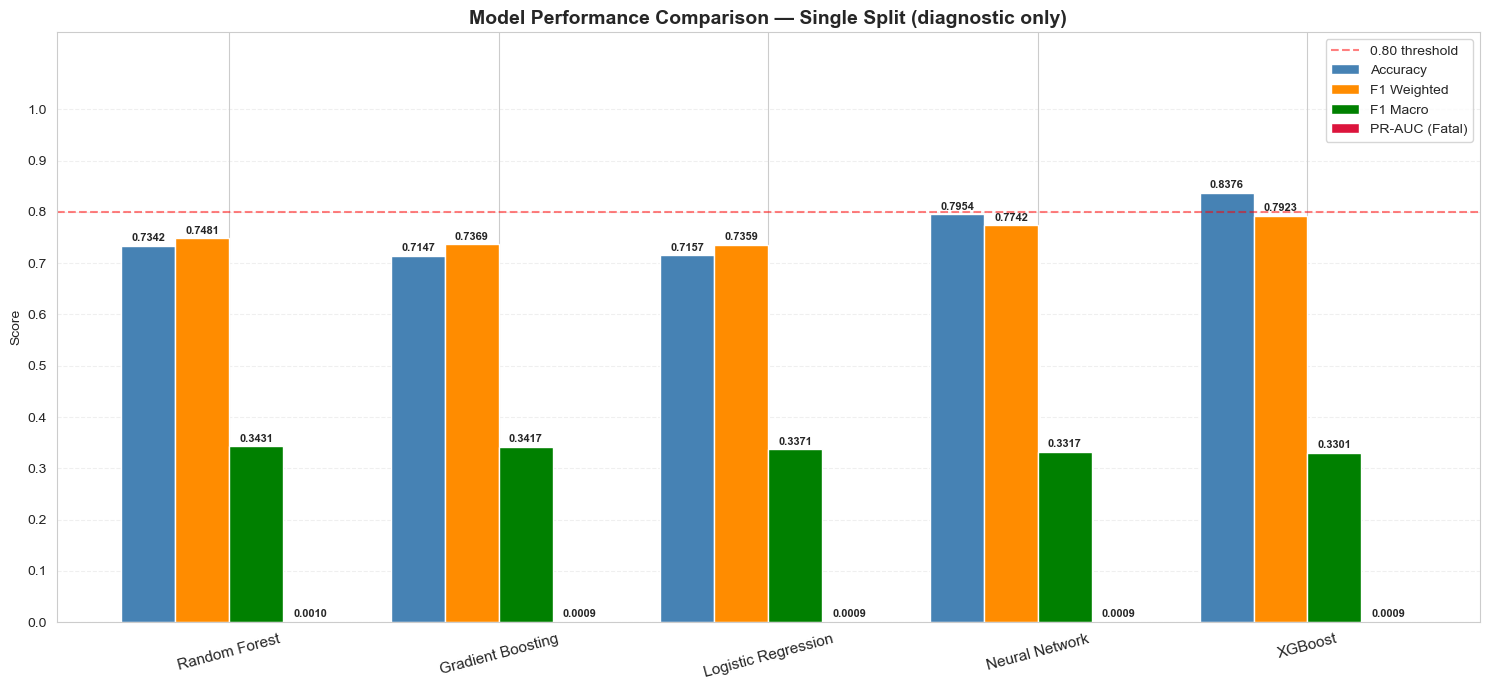

In [11]:
# Comparison bar chart — clean with precise labels
fig, ax = plt.subplots(figsize=(15, 7))
x = np.arange(len(results_df))
w = 0.2

bars1 = ax.bar(x-1.5*w, results_df['Accuracy'],    w, label='Accuracy',    color='steelblue',  edgecolor='white')
bars2 = ax.bar(x-0.5*w, results_df['F1 Weighted'], w, label='F1 Weighted', color='darkorange', edgecolor='white')
bars3 = ax.bar(x+0.5*w, results_df['F1 Macro'],    w, label='F1 Macro',    color='green',       edgecolor='white')
pr_auc_vals = pd.to_numeric(results_df['PR-AUC (Fatal)'], errors='coerce').fillna(0)
bars4 = ax.bar(x+1.5*w, pr_auc_vals,                w, label='PR-AUC (Fatal)', color='crimson', edgecolor='white')

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f'{height:.4f}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='0.80 threshold')
ax.set_title('Model Performance Comparison — Single Split (diagnostic only)', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_09_model_comparison_single_split.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# Best model report (by F1 Macro on this single split)
best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]
y_pred_best     = best_model.predict(X_test)

print(f'Best Model (single split, by F1 Macro): {best_model_name}')
print('='*55)
print(classification_report(y_test, y_pred_best, target_names=['Minor','Major','Fatal']))


Best Model (single split, by F1 Macro): Random Forest
              precision    recall  f1-score   support

       Minor       0.86      0.82      0.84     87074
       Major       0.17      0.21      0.18     14389
       Fatal       0.00      0.01      0.00        96

    accuracy                           0.73    101559
   macro avg       0.34      0.35      0.34    101559
weighted avg       0.76      0.73      0.75    101559



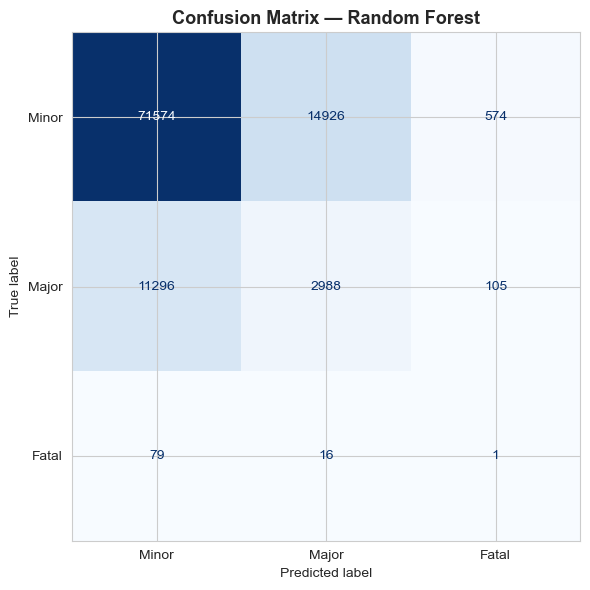

In [13]:
# Confusion matrix — best model
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=['Minor','Major','Fatal']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_10_confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()


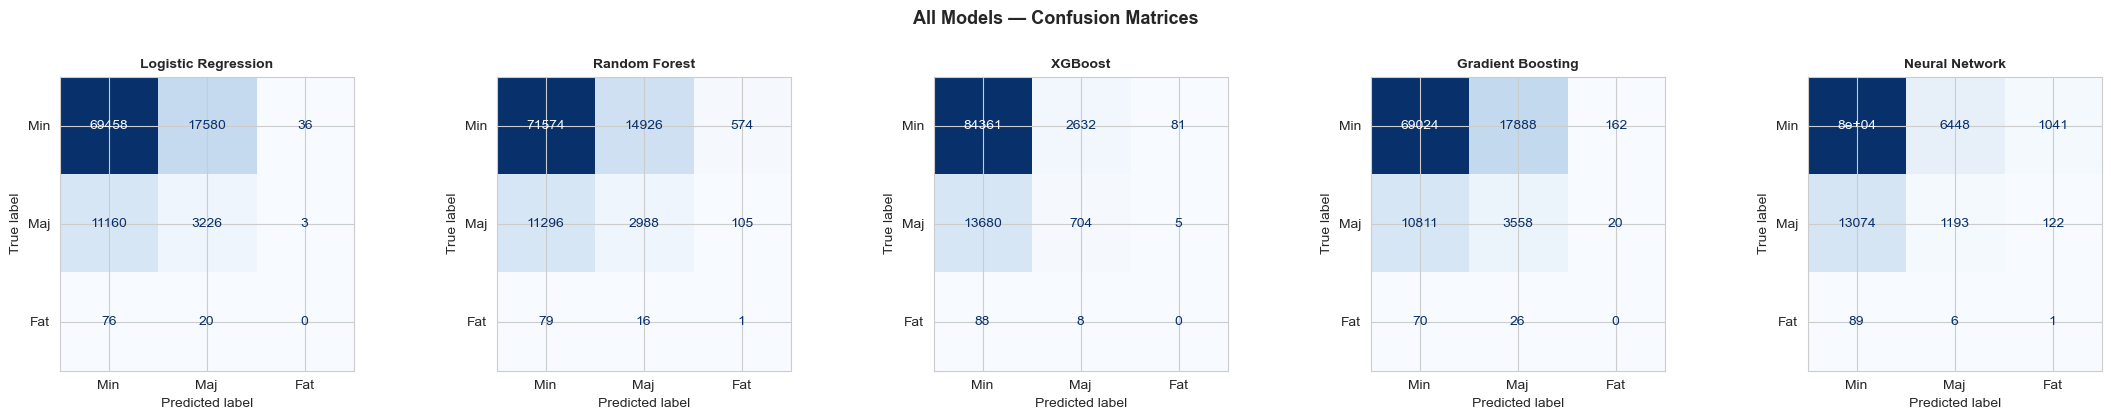

In [14]:
# All 5 confusion matrices
fig, axes = plt.subplots(1,5, figsize=(22,4))
for ax, (name, model) in zip(axes, trained_models.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, model.predict(X_test)),
        display_labels=['Min','Maj','Fat']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=10, fontweight='bold')
plt.suptitle('All Models — Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_11_all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 10 — Subgroup Analysis

In [15]:
df_test = X_test.copy()
df_test['true_severity'] = y_test.values
df_test['pred_severity'] = y_pred_best

# By Season
season_cols = [c for c in df_test.columns if 'season_' in c]
if season_cols:
    df_test['season_label'] = df_test[season_cols].idxmax(axis=1).str.replace('season_','')
    rows = []
    for s, grp in df_test.groupby('season_label'):
        if len(grp) < 10: continue
        rows.append({'Season':s,
                     'F1': round(f1_score(grp['true_severity'],grp['pred_severity'],average='weighted'),4),
                     'Accuracy': round(accuracy_score(grp['true_severity'],grp['pred_severity']),4),
                     'N': len(grp)})
    print('Performance by Season:')
    print(pd.DataFrame(rows).to_string(index=False))


Performance by Season:
Season     F1  Accuracy     N
  Fall 0.7155    0.6882 26318
Spring 0.7834    0.8035 23496
Summer 0.6508    0.5972 24834
Winter 0.8107    0.8450 26911


In [16]:
# By Time of Day
hour_cols = [c for c in df_test.columns if 'hour_category_' in c]
if hour_cols:
    df_test['hour_label'] = df_test[hour_cols].idxmax(axis=1).str.replace('hour_category_','')
    rows = []
    for h, grp in df_test.groupby('hour_label'):
        if len(grp) < 10: continue
        rows.append({'Time':h,
                     'F1': round(f1_score(grp['true_severity'],grp['pred_severity'],average='weighted'),4),
                     'Accuracy': round(accuracy_score(grp['true_severity'],grp['pred_severity']),4),
                     'N': len(grp)})
    print('Performance by Time of Day:')
    print(pd.DataFrame(rows).to_string(index=False))


Performance by Time of Day:
      Time     F1  Accuracy     N
late_night 0.7693    0.8002  5675
   offpeak 0.7949    0.8378 37141
      peak 0.7295    0.7059 34830
   weekend 0.6575    0.5989 23913


In [17]:
# Fatal recall by time
print('Fatal Recall by Time (% of actual fatals correctly caught):')
if 'hour_label' in df_test.columns:
    for h, grp in df_test.groupby('hour_label'):
        fg = grp[grp['true_severity']==2]
        if len(fg)==0: continue
        recall = (fg['pred_severity']==2).sum()/len(fg)
        print(f'  {h:15s}: {recall*100:.1f}%  (n={len(fg)} fatals)')


Fatal Recall by Time (% of actual fatals correctly caught):
  late_night     : 0.0%  (n=21 fatals)
  offpeak        : 3.2%  (n=31 fatals)
  peak           : 0.0%  (n=22 fatals)
  weekend        : 0.0%  (n=22 fatals)


## Step 11 — Balancing Strategy Comparison


In [18]:
from imblearn.over_sampling import SMOTENC, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

balancing_strategies = {
    'No Resampling (Class Weights)': None,
    'SMOTE-NC':                       SMOTENC(categorical_features=categorical_indices, random_state=RANDOM_STATE),
    'ADASYN':                         ADASYN(random_state=RANDOM_STATE),
    'SMOTETomek':                     SMOTETomek(random_state=RANDOM_STATE),
    'Random Undersampling':          RandomUnderSampler(random_state=RANDOM_STATE),
}

print('Strategies to compare:')
for name in balancing_strategies:
    print(f'  - {name}')


Strategies to compare:
  - No Resampling (Class Weights)
  - SMOTE-NC
  - ADASYN
  - SMOTETomek
  - Random Undersampling


In [19]:
# Train XGBoost with each strategy and record results
strategy_results = []

for strategy_name, sampler in balancing_strategies.items():
    print(f'Testing: {strategy_name}...', end=' ')

    if sampler is None:
        X_res, y_res = X_train.copy(), y_train.copy()
        model = XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='mlogloss', random_state=RANDOM_STATE,
            n_jobs=-1, scale_pos_weight=3
        )
    else:
        X_res, y_res = sampler.fit_resample(X_train, y_train)
        model = XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='mlogloss', random_state=RANDOM_STATE,
            n_jobs=-1
        )

    model.fit(X_res, y_res)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    report = classification_report(y_test, y_pred,
                                   target_names=['Minor','Major','Fatal'],
                                   output_dict=True)
    pr_auc_fatal = compute_pr_auc_fatal(y_test, y_proba)

    strategy_results.append({
        'Strategy':       strategy_name,
        'Train Size':     len(X_res),
        'Accuracy':       round(accuracy_score(y_test, y_pred), 4),
        'F1 Weighted':    round(f1_score(y_test, y_pred, average='weighted'), 4),
        'F1 Macro':       round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 Minor':       round(report['Minor']['f1-score'], 4),
        'F1 Major':       round(report['Major']['f1-score'], 4),
        'F1 Fatal':       round(report['Fatal']['f1-score'], 4),
        'Recall Fatal':   round(report['Fatal']['recall'], 4),
        'PR-AUC (Fatal)': round(pr_auc_fatal, 4) if pr_auc_fatal is not None else 'N/A',
    })
    print('Done!')

strategy_df = pd.DataFrame(strategy_results).sort_values('F1 Macro', ascending=False)
print('\nBalancing Strategy Comparison:')
strategy_df


Testing: No Resampling (Class Weights)... 

Done!
Testing: SMOTE-NC... Done!
Testing: ADASYN... Done!
Testing: SMOTETomek... Done!
Testing: Random Undersampling... Done!

Balancing Strategy Comparison:


,Strategy,Train Size,Accuracy,F1 Weighted,F1 Macro,F1 Minor,F1 Major,F1 Fatal,Recall Fatal,PR-AUC (Fatal)
1,SMOTE-NC,1219032,0.8376,0.7923,0.3301,0.9110,0.0794,0.0000,0.0000,0.0009
3,SMOTETomek,1204024,0.8562,0.7924,0.3108,0.9225,0.0100,0.0000,0.0000,0.0012
2,ADASYN,1229713,0.8564,0.7924,0.3107,0.9226,0.0094,0.0000,0.0000,0.0012
0,No Resampling (Class Weights),473939,0.8573,0.7916,0.3079,0.9232,0.0006,0.0000,0.0000,0.0014
4,Random Undersampling,1335,0.3725,0.4798,0.2437,0.5262,0.2020,0.0029,0.4479,0.0070


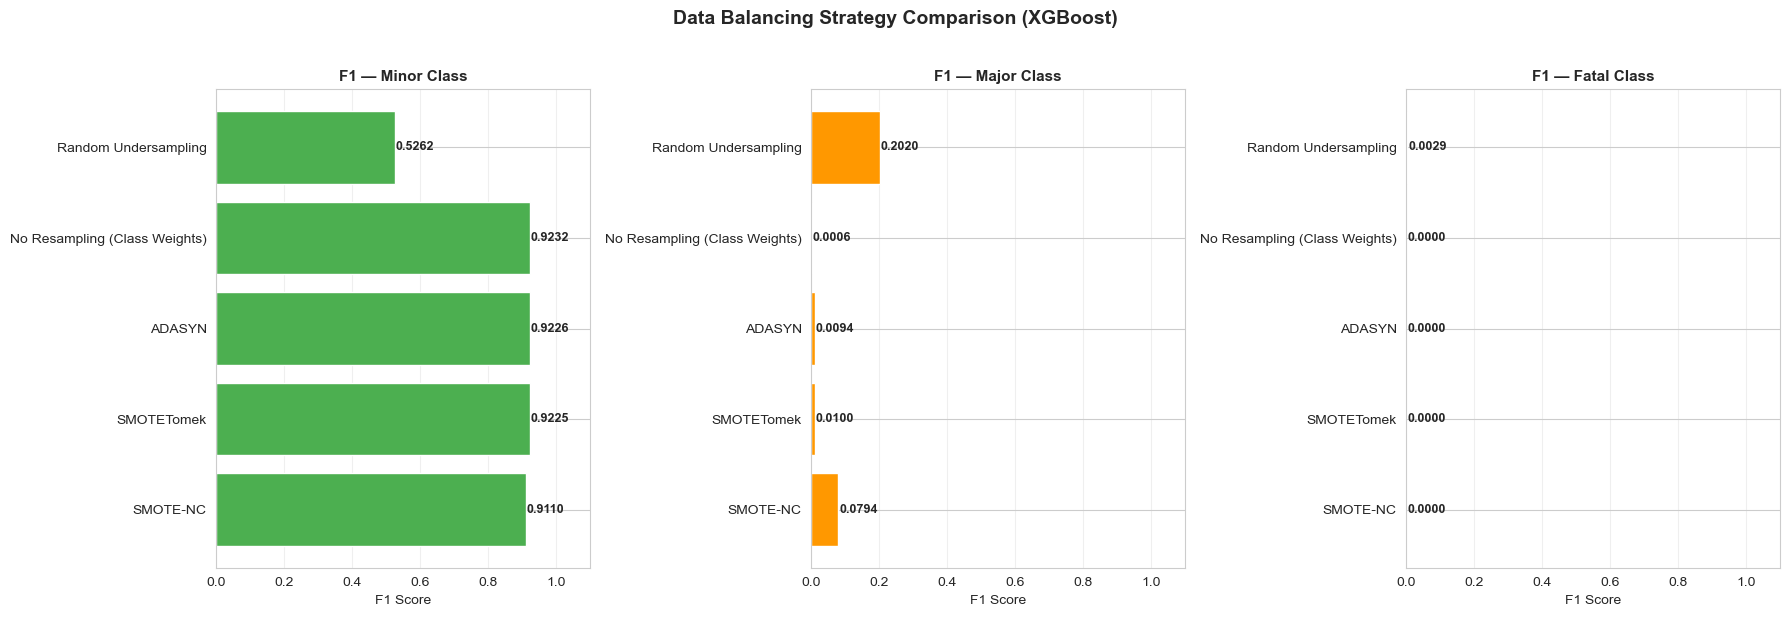

In [20]:
# Plot: F1 per class for each strategy
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['F1 Minor', 'F1 Major', 'F1 Fatal']
colors  = ['#4CAF50', '#FF9800', '#F44336']
titles  = ['F1 — Minor Class', 'F1 — Major Class', 'F1 — Fatal Class']

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    bars = ax.barh(strategy_df['Strategy'], strategy_df[metric],
                   color=color, edgecolor='white')
    for bar, val in zip(bars, strategy_df[metric]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel('F1 Score')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Data Balancing Strategy Comparison (XGBoost)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_12_balancing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


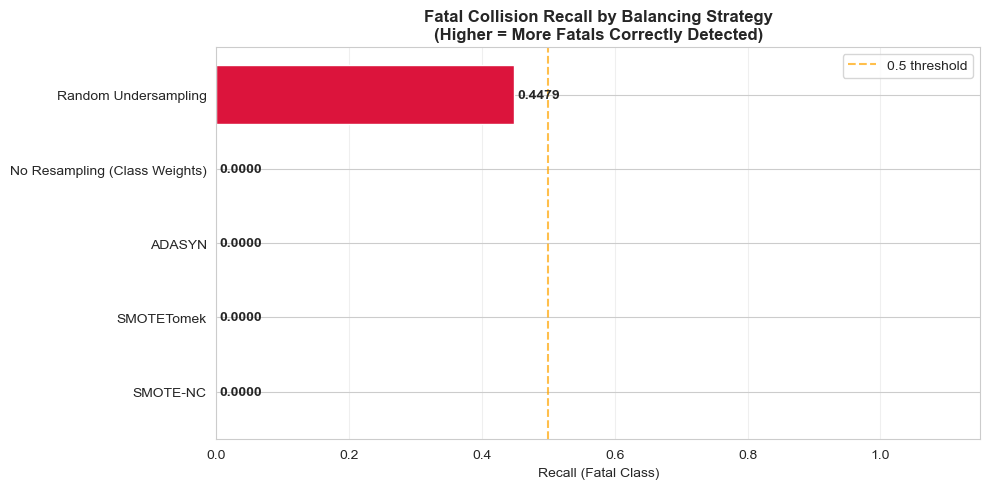


Best strategy for Fatal recall:
  → Random Undersampling

Best overall F1 Macro:
  → SMOTE-NC


In [21]:
# Plot: Fatal recall — most important for safety
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(strategy_df['Strategy'], strategy_df['Recall Fatal'],
               color='crimson', edgecolor='white')
for bar, val in zip(bars, strategy_df['Recall Fatal']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Fatal Collision Recall by Balancing Strategy\n(Higher = More Fatals Correctly Detected)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Recall (Fatal Class)')
ax.set_xlim(0, 1.15)
ax.axvline(0.5, color='orange', linestyle='--', alpha=0.7, label='0.5 threshold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_13_fatal_recall_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nBest strategy for Fatal recall:')
print(f'  → {strategy_df.loc[strategy_df["Recall Fatal"].idxmax(), "Strategy"]}')
print('\nBest overall F1 Macro:')
print(f'  → {strategy_df.loc[strategy_df["F1 Macro"].idxmax(), "Strategy"]}')


## Step 12 — Threshold Tuning

In [22]:
# ── Threshold Tuning — compute dynamically from model ──
xgb_model = trained_models['XGBoost']
y_proba   = xgb_model.predict_proba(X_test)

thresholds      = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
fatal_recalls   = []
fatal_precisions = []
accuracies      = []

print('Fatal Recall at different thresholds:')
print(f'{"Threshold":>10} {"Fatal Recall":>13} {"Fatal Precision":>16} {"Accuracy":>10}')
print('-'*55)

for threshold in thresholds:
    y_pred_thresh = []
    for probs in y_proba:
        if probs[2] >= threshold:
            y_pred_thresh.append(2)
        else:
            y_pred_thresh.append(np.argmax(probs[:2]))

    y_pred_thresh = np.array(y_pred_thresh)
    report = classification_report(y_test, y_pred_thresh,
                                   target_names=['Minor','Major','Fatal'],
                                   output_dict=True, zero_division=0)

    recall    = report['Fatal']['recall']
    precision = report['Fatal']['precision']
    acc       = accuracy_score(y_test, y_pred_thresh)

    fatal_recalls.append(recall)
    fatal_precisions.append(precision)
    accuracies.append(acc)

    print(f'{threshold:>10.2f} {recall:>13.4f} {precision:>16.4f} {acc:>10.4f}')


Fatal Recall at different thresholds:
 Threshold  Fatal Recall  Fatal Precision   Accuracy
-------------------------------------------------------
      0.05        0.1354           0.0011     0.7399
      0.10        0.0417           0.0009     0.8015
      0.15        0.0104           0.0005     0.8205
      0.20        0.0104           0.0009     0.8291
      0.30        0.0104           0.0032     0.8357
      0.50        0.0000           0.0000     0.8381


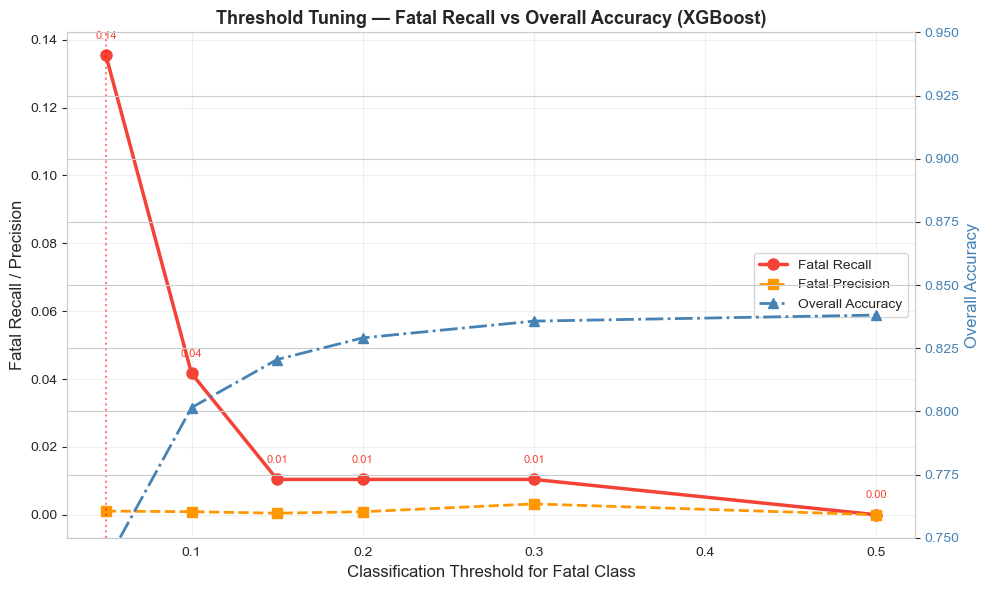

Recommended threshold: 0.05
  Fatal Recall: 0.0000 → 0.1354 (+13.5%)
  Accuracy:     0.8381 → 0.7399 (-9.8%)
  For road safety: higher recall is more important than accuracy

NOTE: if you report the number of records flagged for review at the recommended
threshold (e.g. for an operational-workload claim), back it up with real analyst
throughput/triage-volume numbers, or leave the workload claim out.


In [23]:
# ── Plot dynamically using computed values ──
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = '#F44336'
color2 = 'steelblue'
color3 = '#FF9800'

ax1.plot(thresholds, fatal_recalls,    'o-',  color=color1, linewidth=2.5, markersize=8, label='Fatal Recall')
ax1.plot(thresholds, fatal_precisions, 's--', color=color3, linewidth=2,   markersize=7, label='Fatal Precision')
ax1.set_xlabel('Classification Threshold for Fatal Class', fontsize=12)
ax1.set_ylabel('Fatal Recall / Precision', fontsize=12)

ax2 = ax1.twinx()
ax2.plot(thresholds, accuracies, '^-.', color=color2, linewidth=2, markersize=7, label='Overall Accuracy')
ax2.set_ylabel('Overall Accuracy', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0.75, 0.95)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)

ax1.set_title('Threshold Tuning — Fatal Recall vs Overall Accuracy (XGBoost)',
              fontsize=13, fontweight='bold')
ax1.axvline(x=0.05, color='red', linestyle=':', alpha=0.5)
ax1.grid(alpha=0.3)

for i, t in enumerate(thresholds):
    ax1.annotate(f'{fatal_recalls[i]:.2f}',
                 (t, fatal_recalls[i]),
                 textcoords='offset points', xytext=(0, 12),
                 ha='center', fontsize=8, color=color1)

plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_14_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Print recommendation based on actual computed values
best_threshold_idx = max(range(len(thresholds)),
                         key=lambda i: fatal_recalls[i])
best_threshold     = thresholds[best_threshold_idx]
best_recall        = fatal_recalls[best_threshold_idx]
default_recall     = fatal_recalls[thresholds.index(0.50)]
default_acc        = accuracies[thresholds.index(0.50)]
best_acc           = accuracies[best_threshold_idx]

print(f'Recommended threshold: {best_threshold}')
print(f'  Fatal Recall: {default_recall:.4f} → {best_recall:.4f} '
      f'(+{(best_recall-default_recall)*100:.1f}%)')
print(f'  Accuracy:     {default_acc:.4f} → {best_acc:.4f} '
      f'({(best_acc-default_acc)*100:.1f}%)')
print(f'  For road safety: higher recall is more important than accuracy')
print()
print('NOTE: if you report the number of records flagged for review at the recommended')
print('threshold (e.g. for an operational-workload claim), back it up with real analyst')
print('throughput/triage-volume numbers, or leave the workload claim out.')


## Step 13 — Hyperparameter Tuning

Using RandomizedSearchCV on XGBoost and Random Forest, on the SMOTE-NC-resampled training data. PR-AUC (Fatal) added to the tuned-vs-default comparison.

In [24]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
print('Hyperparameter tuning setup ready!')
print('Will tune: XGBoost and Random Forest')
print('Method: RandomizedSearchCV (20 combinations × 3 folds = 60 fits each)')


Hyperparameter tuning setup ready!
Will tune: XGBoost and Random Forest
Method: RandomizedSearchCV (20 combinations × 3 folds = 60 fits each)


In [25]:
# ── Tune XGBoost ──
xgb_param_grid = {
    'n_estimators':      randint(100, 400),
    'max_depth':         randint(3, 10),
    'learning_rate':     uniform(0.01, 0.3),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'min_child_weight':  randint(1, 10)
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring='f1_macro',
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Tuning XGBoost...')
t = time.time()
xgb_search.fit(X_train_sm, y_train_sm)
print(f'Done in {(time.time()-t)/60:.1f} minutes')
print(f'\nBest XGBoost parameters:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k:25s}: {round(v, 4) if isinstance(v, float) else v}')
print(f'\nBest CV F1 Macro: {xgb_search.best_score_:.4f}')


Tuning XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Done in 45.7 minutes

Best XGBoost parameters:
  colsample_bytree         : 0.7867
  learning_rate            : 0.268
  max_depth                : 9
  min_child_weight         : 5
  n_estimators             : 266
  subsample                : 0.6053

Best CV F1 Macro: 0.9308


In [33]:
# ── Tune Random Forest — memory optimized ──
sample_size = 200000
rng         = np.random.RandomState(RANDOM_STATE)
idx_sample  = rng.choice(len(X_train_sm), sample_size, replace=False)
X_train_rf  = X_train_sm.iloc[idx_sample]
y_train_rf  = y_train_sm.iloc[idx_sample]

print(f'Using {sample_size:,} row sample for RF tuning (memory optimized)')

rf_param_grid = {
    'n_estimators':      randint(100, 300),
    'max_depth':         randint(5, 20),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf':  randint(1, 8),
    'max_features':      ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=2
    ),
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring='f1_macro',
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=1
)

print('Tuning Random Forest...')
t = time.time()
rf_search.fit(X_train_rf, y_train_rf)
print(f'Done in {(time.time()-t)/60:.1f} minutes')
print(f'\nBest Random Forest parameters:')
for k, v in rf_search.best_params_.items():
    print(f'  {k:25s}: {round(v, 4) if isinstance(v, float) else v}')
print(f'\nBest CV F1 Macro: {rf_search.best_score_:.4f}')


Using 200,000 row sample for RF tuning (memory optimized)
Tuning Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Done in 19.8 minutes

Best Random Forest parameters:
  max_depth                : 19
  max_features             : log2
  min_samples_leaf         : 6
  min_samples_split        : 4
  n_estimators             : 207

Best CV F1 Macro: 0.8053


In [34]:
# ── Compare tuned vs default (now includes PR-AUC (Fatal)) ──
tuned_results = []

for name, search in [('XGBoost (Tuned)', xgb_search),
                     ('Random Forest (Tuned)', rf_search)]:
    y_pred  = search.best_estimator_.predict(X_test)
    y_proba = search.best_estimator_.predict_proba(X_test)
    try:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except Exception:
        auc = None
    pr_auc_fatal = compute_pr_auc_fatal(y_test, y_proba)

    report = classification_report(
        y_test, y_pred,
        target_names=['Minor','Major','Fatal'],
        output_dict=True, zero_division=0)

    tuned_results.append({
        'Model':          name,
        'Accuracy':       round(accuracy_score(y_test, y_pred), 4),
        'F1 Weighted':    round(f1_score(y_test, y_pred, average='weighted'), 4),
        'F1 Macro':       round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 Fatal':       round(report['Fatal']['f1-score'], 4),
        'Recall Fatal':   round(report['Fatal']['recall'], 4),
        'ROC-AUC':        round(auc, 4) if auc else 'N/A',
        'PR-AUC (Fatal)': round(pr_auc_fatal, 4) if pr_auc_fatal is not None else 'N/A',
    })

tuned_df = pd.DataFrame(tuned_results)

default_rows = []
for name in ['XGBoost', 'Random Forest']:
    model   = trained_models[name]
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    report = classification_report(y_test, y_pred,
                                   target_names=['Minor','Major','Fatal'],
                                   output_dict=True, zero_division=0)
    try:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except Exception:
        auc = None
    pr_auc_fatal = compute_pr_auc_fatal(y_test, y_proba)

    default_rows.append({
        'Model':          f'{name} (Default)',
        'Accuracy':       round(accuracy_score(y_test, y_pred), 4),
        'F1 Weighted':    round(f1_score(y_test, y_pred, average='weighted'), 4),
        'F1 Macro':       round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 Fatal':       round(report['Fatal']['f1-score'], 4),
        'Recall Fatal':   round(report['Fatal']['recall'], 4),
        'ROC-AUC':        round(auc, 4) if auc else 'N/A',
        'PR-AUC (Fatal)': round(pr_auc_fatal, 4) if pr_auc_fatal is not None else 'N/A',
    })

comparison_df = pd.concat(
    [tuned_df, pd.DataFrame(default_rows)],
    ignore_index=True
).sort_values('F1 Macro', ascending=False)

print('Tuned vs Default Comparison:')
comparison_df


Tuned vs Default Comparison:


,Model,Accuracy,F1 Weighted,F1 Macro,F1 Fatal,Recall Fatal,ROC-AUC,PR-AUC (Fatal)
1,Random Forest (Tuned),0.7514,0.7575,0.3449,0.0000,0.0000,0.5404,0.0010
3,Random Forest (Default),0.7342,0.7481,0.3431,0.0026,0.0104,0.5222,0.0010
2,XGBoost (Default),0.8376,0.7923,0.3301,0.0000,0.0000,0.5541,0.0009
0,XGBoost (Tuned),0.8531,0.7931,0.3157,0.0000,0.0000,0.5716,0.0012


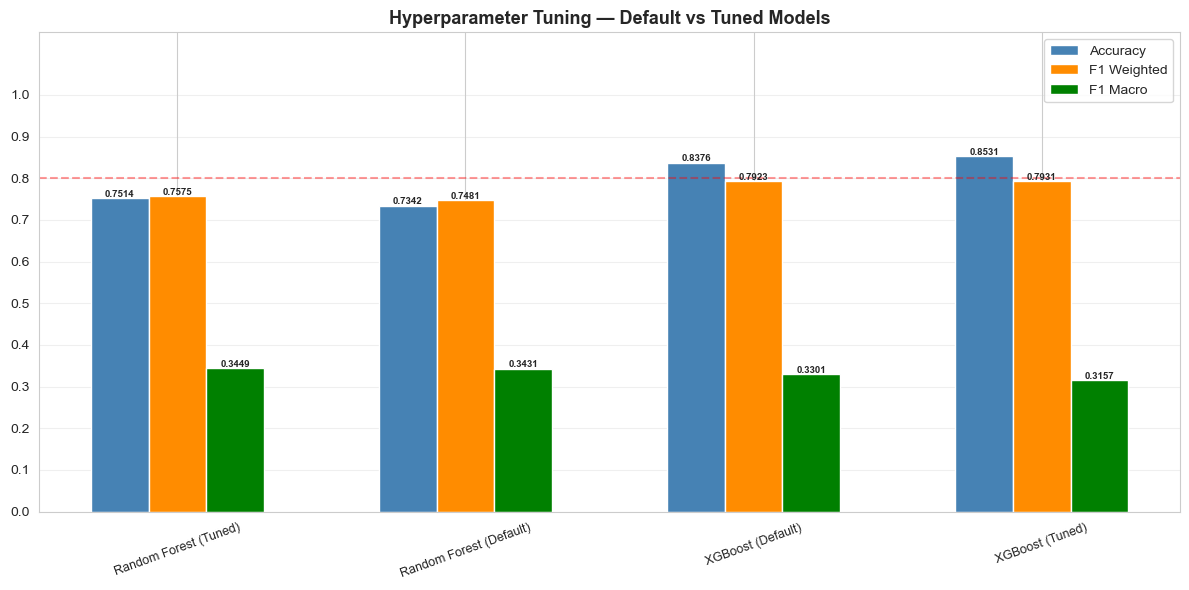

Best hyperparameters saved!
        Model         Parameter Best Value
      XGBoost  colsample_bytree     0.7867
      XGBoost     learning_rate      0.268
      XGBoost         max_depth          9
      XGBoost  min_child_weight          5
      XGBoost      n_estimators        266
      XGBoost         subsample     0.6053
Random Forest         max_depth         19
Random Forest      max_features       log2
Random Forest  min_samples_leaf          6
Random Forest min_samples_split          4
Random Forest      n_estimators        207

Tuned models saved to trained_models.pkl


In [35]:
# ── Bar chart: Tuned vs Default ──
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
w = 0.2

ax.bar(x-w,  comparison_df['Accuracy'],    w, label='Accuracy',    color='steelblue',  edgecolor='white')
ax.bar(x,    comparison_df['F1 Weighted'], w, label='F1 Weighted', color='darkorange', edgecolor='white')
ax.bar(x+w,  comparison_df['F1 Macro'],   w, label='F1 Macro',    color='green',      edgecolor='white')

for bars in [ax.containers[0], ax.containers[1], ax.containers[2]]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.003,
                f'{h:.4f}', ha='center', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=20, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_yticks([0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])
ax.axhline(0.8, color='red', linestyle='--', alpha=0.4)
ax.set_title('Hyperparameter Tuning — Default vs Tuned Models',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_15_hyperparameter_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save best parameters to CSV
params_records = []
for name, search in [('XGBoost', xgb_search), ('Random Forest', rf_search)]:
    for param, value in search.best_params_.items():
        params_records.append({
            'Model':      name,
            'Parameter':  param,
            'Best Value': round(value, 4) if isinstance(value, float) else value
        })

params_df = pd.DataFrame(params_records)
params_df.to_csv(f'{MODELS_FOLDER}best_hyperparameters.csv', index=False)
print('Best hyperparameters saved!')
print(params_df.to_string(index=False))

# Save tuned models
trained_models['XGBoost (Tuned)']       = xgb_search.best_estimator_
trained_models['Random Forest (Tuned)'] = rf_search.best_estimator_
with open(f'{MODELS_FOLDER}trained_models.pkl', 'wb') as f:
    pickle.dump(trained_models, f)
print('\nTuned models saved to trained_models.pkl')


## Step 14 — Cross-Validation (Full Dataset, Mean ± SD) — THE HEADLINE MODEL COMPARISON

- Runs on the **full dataset** (all of `X`, `y` — not a sample)
- Evaluates **all 5 default-parameter models** — the same ones compared in Step 9, so this
  is a direct, reconciled replacement for that comparison, not a separate side experiment
- Applies **SMOTE-NC inside each fold** via a pipeline, so no fold ever sees synthetic points
  derived from data outside its own training portion (this also closes a subtler leakage
  risk in the old approach, which resampled once outside the CV loop)
- Reports **mean ± standard deviation** for Accuracy, F1 Weighted, F1 Macro, ROC-AUC, and
  PR-AUC (Fatal)
- Gets saved as `model_results.csv` — the file Notebook 5 reads



In [36]:
# ── Config — adjust if runtime is prohibitive on your machine ──
CV_N_SPLITS = 5
CV_MODELS   = list(models.keys())   # all 5 by default; trim this list to speed up

def pr_auc_fatal_scorer_fn(y_true, y_proba):
    y_true_bin = (np.array(y_true) == 2).astype(int)
    if y_true_bin.sum() == 0:
        return 0.0
    return average_precision_score(y_true_bin, y_proba[:, 2])

try:
    pr_auc_fatal_scorer = make_scorer(pr_auc_fatal_scorer_fn, response_method='predict_proba')
except TypeError:
    # older scikit-learn versions use needs_proba instead of response_method
    pr_auc_fatal_scorer = make_scorer(pr_auc_fatal_scorer_fn, needs_proba=True)

cv_scoring = {
    'accuracy':     'accuracy',
    'f1_weighted':  'f1_weighted',
    'f1_macro':     'f1_macro',
    'roc_auc':      'roc_auc_ovr_weighted',
    'pr_auc_fatal': pr_auc_fatal_scorer,
}

skf_full = StratifiedKFold(n_splits=CV_N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f'Running {CV_N_SPLITS}-fold CV on the FULL dataset ({len(X):,} rows) for: {CV_MODELS}')
print('This can take a long time depending on your machine.')
print()

cv_all_results = {}
for name in CV_MODELS:
    print(f'CV for {name}...', end=' ', flush=True)
    t0 = time.time()
    pipe = ImbPipeline([
        ('smote_nc', SMOTENC(categorical_features=categorical_indices,
                              random_state=RANDOM_STATE, k_neighbors=5)),
        ('clf', models[name])
    ])
    res = cross_validate(pipe, X, y, cv=skf_full, scoring=cv_scoring, n_jobs=1)
    cv_all_results[name] = res
    print(f'done in {(time.time()-t0)/60:.1f} min')


Running 5-fold CV on the FULL dataset (677,056 rows) for: ['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting', 'Neural Network']
This can take a long time depending on your machine.

CV for Logistic Regression... done in 149.0 min
CV for Random Forest... done in 82.2 min
CV for XGBoost... done in 87.3 min
CV for Gradient Boosting... done in 268.6 min
CV for Neural Network... done in 193.0 min


In [37]:
cv_summary_rows = []
for name, res in cv_all_results.items():
    cv_summary_rows.append({
        'Model':             name,
        'Accuracy Mean':     round(res['test_accuracy'].mean(), 4),
        'Accuracy Std':      round(res['test_accuracy'].std(), 4),
        'F1 Weighted Mean':  round(res['test_f1_weighted'].mean(), 4),
        'F1 Weighted Std':   round(res['test_f1_weighted'].std(), 4),
        'F1 Macro Mean':     round(res['test_f1_macro'].mean(), 4),
        'F1 Macro Std':      round(res['test_f1_macro'].std(), 4),
        'ROC-AUC Mean':      round(res['test_roc_auc'].mean(), 4),
        'ROC-AUC Std':       round(res['test_roc_auc'].std(), 4),
        'PR-AUC Fatal Mean': round(res['test_pr_auc_fatal'].mean(), 4),
        'PR-AUC Fatal Std':  round(res['test_pr_auc_fatal'].std(), 4),
    })

cv_results_df = pd.DataFrame(cv_summary_rows).sort_values('F1 Macro Mean', ascending=False).reset_index(drop=True)
cv_results_df.to_csv(f'{MODELS_FOLDER}model_results.csv', index=False)
cv_results_df.to_csv(f'{MODELS_FOLDER}cv_results.csv', index=False)  # kept for backward compatibility

print('='*70)
print('  HEADLINE MODEL COMPARISON — CROSS-VALIDATED MEAN ± SD (Full Dataset)')
print('='*70)
print('Saved as model_results.csv — this is the primary reported result.')
cv_results_df


  HEADLINE MODEL COMPARISON — CROSS-VALIDATED MEAN ± SD (Full Dataset)
Saved as model_results.csv — this is the primary reported result.


,Model,Accuracy Mean,Accuracy Std,F1 Weighted Mean,F1 Weighted Std,F1 Macro Mean,F1 Macro Std,ROC-AUC Mean,ROC-AUC Std,PR-AUC Fatal Mean,PR-AUC Fatal Std
0,Gradient Boosting,0.7122,0.0103,0.7351,0.0060,0.3428,0.0027,0.5356,0.0020,0.0025,0.0013
1,Random Forest,0.7124,0.0110,0.7355,0.0058,0.3392,0.0021,0.5246,0.0023,0.0017,0.0007
2,Logistic Regression,0.7043,0.0018,0.7295,0.0012,0.3367,0.0006,0.5225,0.0021,0.0010,0.0001
3,XGBoost,0.8333,0.0014,0.7911,0.0007,0.3335,0.0011,0.5502,0.0025,0.0018,0.0006
4,Neural Network,0.7074,0.0362,0.7300,0.0223,0.3333,0.0040,0.5171,0.0036,0.0010,0.0001


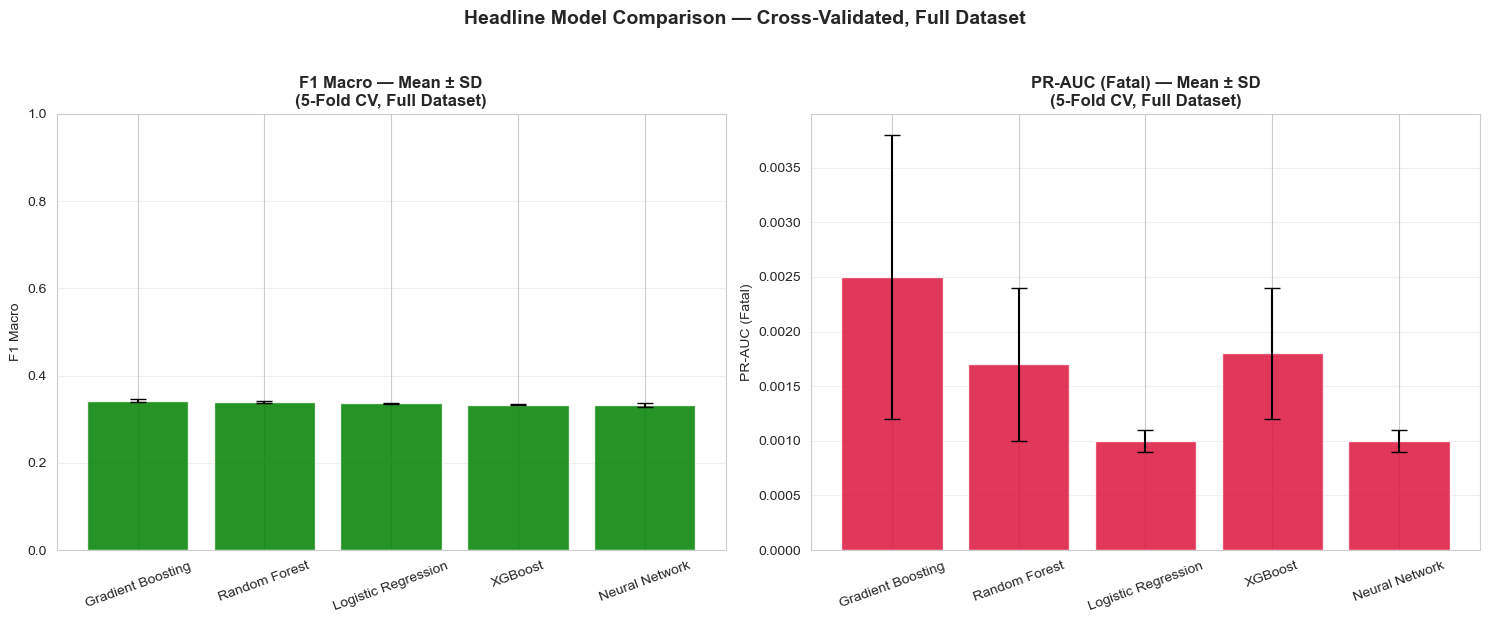

Best model by CV F1 Macro (the headline metric): Gradient Boosting
  F1 Macro:      0.3428 ± 0.0027
  PR-AUC (Fatal): 0.0025 ± 0.0013


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

axes[0].bar(cv_results_df['Model'], cv_results_df['F1 Macro Mean'],
            yerr=cv_results_df['F1 Macro Std'], capsize=6,
            color='green', edgecolor='white', alpha=0.85)
axes[0].set_title('F1 Macro — Mean ± SD\n(5-Fold CV, Full Dataset)', fontweight='bold')
axes[0].set_ylabel('F1 Macro')
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3)
plt.setp(axes[0].get_xticklabels(), rotation=20)

axes[1].bar(cv_results_df['Model'], cv_results_df['PR-AUC Fatal Mean'],
            yerr=cv_results_df['PR-AUC Fatal Std'], capsize=6,
            color='crimson', edgecolor='white', alpha=0.85)
axes[1].set_title('PR-AUC (Fatal) — Mean ± SD\n(5-Fold CV, Full Dataset)', fontweight='bold')
axes[1].set_ylabel('PR-AUC (Fatal)')
axes[1].grid(axis='y', alpha=0.3)
plt.setp(axes[1].get_xticklabels(), rotation=20)

plt.suptitle('Headline Model Comparison — Cross-Validated, Full Dataset',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_16_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

cv_best_model_name = cv_results_df.iloc[0]['Model']
print(f'Best model by CV F1 Macro (the headline metric): {cv_best_model_name}')
print(f'  F1 Macro:      {cv_results_df.iloc[0]["F1 Macro Mean"]:.4f} ± {cv_results_df.iloc[0]["F1 Macro Std"]:.4f}')
print(f'  PR-AUC (Fatal): {cv_results_df.iloc[0]["PR-AUC Fatal Mean"]:.4f} ± {cv_results_df.iloc[0]["PR-AUC Fatal Std"]:.4f}')


## Final Summary

In [39]:
print('='*65)
print('  NOTEBOOK 4 SUMMARY')
print('='*65)
print(f'\nHEADLINE RESULT (cross-validated, full dataset, mean ± SD):')
print(cv_results_df.to_string(index=False))
print(f'\nBest model (CV F1 Macro): {cv_best_model_name}')
print(f'\nSingle-split diagnostic best model (confusion matrix etc.): {best_model_name}')
print(f'\nSaved to: {MODELS_FOLDER}')
print(f'  - trained_models.pkl              (fitted models for Notebook 5)')
print(f'  - X_test.csv / y_test.csv         (held-out test set for Notebook 5)')
print(f'  - model_results.csv               (HEADLINE — CV mean ± SD, read by Notebook 5)')
print(f'  - model_results_single_split.csv  (diagnostic only)')
print(f'  - cv_results.csv                  (duplicate of model_results.csv)')
print(f'  - best_hyperparameters.csv')
print('\n✅ Notebook 4 complete! Open Notebook 5 next.')


  NOTEBOOK 4 SUMMARY

HEADLINE RESULT (cross-validated, full dataset, mean ± SD):
              Model  Accuracy Mean  Accuracy Std  F1 Weighted Mean  F1 Weighted Std  F1 Macro Mean  F1 Macro Std  ROC-AUC Mean  ROC-AUC Std  PR-AUC Fatal Mean  PR-AUC Fatal Std
  Gradient Boosting         0.7122        0.0103            0.7351           0.0060         0.3428        0.0027        0.5356       0.0020             0.0025            0.0013
      Random Forest         0.7124        0.0110            0.7355           0.0058         0.3392        0.0021        0.5246       0.0023             0.0017            0.0007
Logistic Regression         0.7043        0.0018            0.7295           0.0012         0.3367        0.0006        0.5225       0.0021             0.0010            0.0001
            XGBoost         0.8333        0.0014            0.7911           0.0007         0.3335        0.0011        0.5502       0.0025             0.0018            0.0006
     Neural Network         0.707